Homework 8 – Geopandas Geoprocessing techniques

By Antoaneta Chakarova for Geog592

10/05/2026

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_directory = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data"

community_path = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data/Community_Floodplain/Community_Floodplain.shp"
fema_path = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data/FEMA_Floodplain/FEMA_Floodplain.shp"
drainage_path = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data/drainage.geojson"
fire_path = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data/Current_CFD_Fire_Stations.geojson"
streets_path = "C:/Users/Tony/Documents/Fall2026/Geog592/geog592-achakaro/homework/week07/data/streets.geojson"

community = gpd.read_file(community_path)
fema = gpd.read_file(fema_path)
drainage = gpd.read_file(drainage_path)
fire = gpd.read_file(fire_path)
streets = gpd.read_file(streets_path)

In [3]:
print("Community floodplain:", community.shape, community.crs)
print("FEMA floodplain:", fema.shape, fema.crs)
print("Drainage:", drainage.shape, drainage.crs)
print("Fire stations:", fire.shape, fire.crs)
print("Streets:", streets.shape, streets.crs)

print("FEMA columns:")
print(list(fema.columns))

print("Fire station columns:")
print(list(fire.columns))

print("Street columns:")
print(list(streets.columns))

Community floodplain: (354, 6) PROJCS["NAD83 / North Carolina (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",33.75],PARAMETER["central_meridian",-79],PARAMETER["standard_parallel_1",34.3333333333333],PARAMETER["standard_parallel_2",36.1666666666667],PARAMETER["false_easting",2000000.00261667],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
FEMA floodplain: (372, 6) PROJCS["NAD83 / North Carolina (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_o

In [4]:
print("Community:", community.crs, community.total_bounds)
print("FEMA:", fema.crs, fema.total_bounds)
print("Drainage:", drainage.crs, drainage.total_bounds)
print("Fire:", fire.crs, fire.total_bounds)
print("Streets:", streets.crs, streets.total_bounds)

print()
print("Drainage geometry:", drainage.geom_type.value_counts())
print("Fire geometry:", fire.geom_type.value_counts())
print("Streets geometry:", streets.geom_type.value_counts())

Community: PROJCS["NAD83 / North Carolina (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",33.75],PARAMETER["central_meridian",-79],PARAMETER["standard_parallel_1",34.3333333333333],PARAMETER["standard_parallel_2",36.1666666666667],PARAMETER["false_easting",2000000.00261667],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]] [1395269.24990611  460833.05195218 1533490.87110011  644790.61448252]
FEMA: PROJCS["NAD83 / North Carolina (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_

In [5]:
target_crs = "EPSG:2264"

community = community.to_crs(target_crs)
fema = fema.to_crs(target_crs)
drainage = drainage.to_crs(target_crs)
fire = fire.to_crs(target_crs)
streets = streets.to_crs(target_crs)

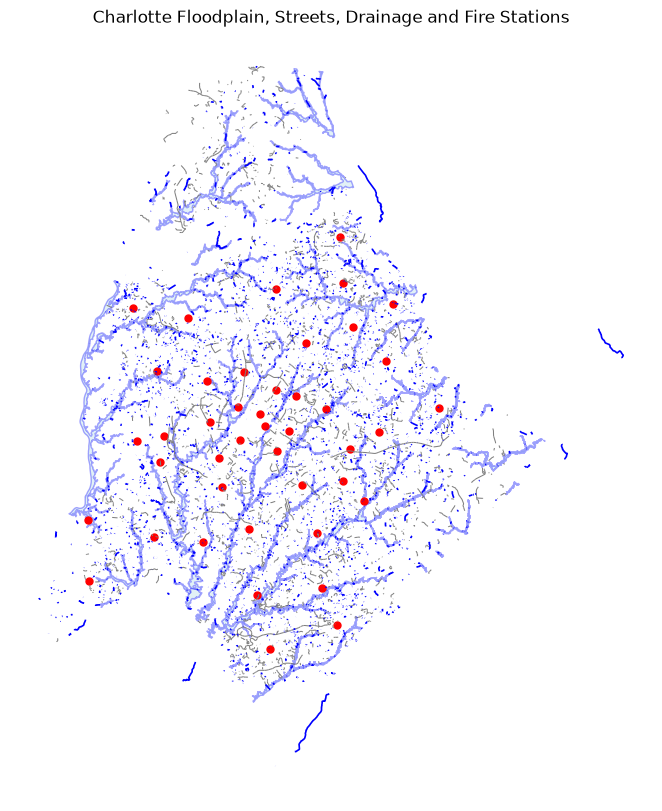

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

community.plot(ax=ax, color="lightblue", alpha=0.35, edgecolor="blue")
streets.plot(ax=ax, color="gray", linewidth=0.75)
drainage.plot(ax=ax, color="blue", linewidth=1.2)
fire.plot(ax=ax, color="red", markersize=25)

ax.set_title("Charlotte Floodplain, Streets, Drainage and Fire Stations")
ax.set_axis_off()
plt.show()

Layer 1: Flood-Exposed Streets

In [7]:
flood_exposed_streets = gpd.sjoin(streets, community, how="inner", predicate="intersects")
flood_exposed_streets = flood_exposed_streets.drop_duplicates(subset="OBJECTID")
flood_exposed_streets.head()

,OBJECTID,ENABLED,E911,LASTEDITDATE,DATEADDED,USERNAME,ACTIONTYPE,PREFIXDIRECTION,STREETNAME,STANDTYPE,...,LOAD_STATUS,FULL_NAME,SHAPE.STLength(),geometry,index_right,STATUS,FLD_ZONE,DATE,Shape_Leng,Shape_Area
55,18738037,1,17179,1604043427000,946512000000,SCASTONGIA,ModifyCL,None,ABELINE,RD,...,None,1200 - 1224 ABELINE RD,207.602050,"LINESTRING (1432904.247 532846.083, 1432835.66...",136,EFFECTIVE,COMMUNITY FLOODPLAIN - FUTURE CONDITIONS,2015-09-02,50661.153326,7.452365e+06
57,18738039,1,8889,1604040171000,946512000000,SCASTONGIA,AddressChange,None,ABELWOOD,RD,...,None,2232 - 2238 ABELWOOD RD,77.630719,"LINESTRING (1443367.164 557514.583, 1443401.41...",239,EFFECTIVE,COMMUNITY FLOODPLAIN - FUTURE CONDITIONS,2015-09-02,25198.983788,3.873224e+06
58,18738040,1,9212,1604040171000,946512000000,SCASTONGIA,AddressChange,None,ABELWOOD,RD,...,None,2208 - 2226 ABELWOOD RD,290.614707,"LINESTRING (1443240.163 557253.25, 1443265.914...",239,EFFECTIVE,COMMUNITY FLOODPLAIN - FUTURE CONDITIONS,2015-09-02,25198.983788,3.873224e+06
59,18738041,1,11050,1604040171000,946512000000,SCASTONGIA,AddressChange,None,ABELWOOD,RD,...,None,2300 - 2320 ABELWOOD RD,517.435528,"LINESTRING (1443401.413 557584.25, 1443415.247...",239,EFFECTIVE,COMMUNITY FLOODPLAIN - FUTURE CONDITIONS,2015-09-02,25198.983788,3.873224e+06
62,18738044,1,10638,1604040245000,946512000000,SCASTONGIA,AddressChange,None,ABELWOOD,RD,...,None,2100 - 2200 ABELWOOD RD,540.172806,"LINESTRING (1443104.58 556751.333, 1443083.997...",239,EFFECTIVE,COMMUNITY FLOODPLAIN - FUTURE CONDITIONS,2015-09-02,25198.983788,3.873224e+06


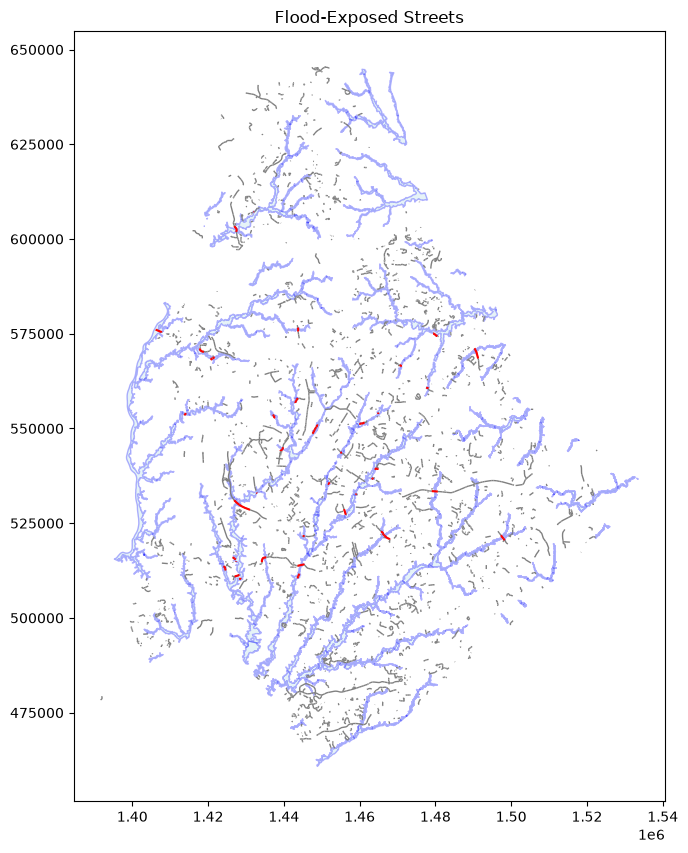

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

community.plot(ax=ax, color="lightblue", alpha=0.3, edgecolor="blue")
streets.plot(ax=ax, color="gray", linewidth=1)
flood_exposed_streets.plot(ax=ax, color="red", linewidth=1.5)

ax.set_title("Flood-Exposed Streets")
plt.show()

In [9]:
flood_exposed_streets.to_file(f"{data_directory}/flood_exposed_streets.geojson",driver="GeoJSON")

Layer 2: Stations near Drainage

In [10]:
drainage_buffer = drainage.copy()
drainage_buffer["geometry"] = drainage.buffer(500)
drainage_buffer.head()

,CHAN_ID,STR_NAME,CH_SHAPE,CH_MAT,WIDTH_TOP,WIDTH_BTTM,DEPTH,FUNCTION_,STD_CMMNT,MEDIA_LINK,...,Editor,AssetID,ITPIPE_ASSETID,US_ASSETID,DS_ASSETID,maintby,ownedby,lifecyclestatus,Shape.STLength(),geometry
0,LON304-0317-CH,None,Trapezoid,Earthen,6.0,2.0,2.0,None,None,P:\Inventory\LON304_200911\Lon304_6377.jpg,...,96278@CHARLOTTE,371,D_371,S_89454,S_89451,None,None,None,392.257518,"POLYGON ((1445580.947 575242.566, 1445548.793 ..."
1,MAL349-7582-CH,None,Irregular,Earthen,6.0,4.0,2.0,None,None,None,...,96278@CHARLOTTE,41980,D_41980,S_265920,S_101677,None,None,None,303.266270,"POLYGON ((1473919.113 586843.496, 1473930.41 5..."
2,BS21207-CH,None,V-Shaped,Grass,4.0,2.0,1.0,None,None,None,...,96278@CHARLOTTE,49857,D_49857,S_291847,S_291848,None,None,None,106.663066,"POLYGON ((1474615.064 559259.884, 1474662.188 ..."
3,JLM471-CH,None,Trapezoid,Earthen,13.0,7.0,3.0,None,None,None,...,96278@CHARLOTTE,53373,D_53373,S_5247,S_427989,None,None,None,4.010681,"POLYGON ((1452910.156 467724.216, 1452936.44 4..."
4,DM.JE.0293-CH,None,Trapezoid,Earthen,3.0,2.0,1.0,None,None,None,...,96278@CHARLOTTE,71152,D_71152,S_512019,S_512021,None,None,None,682.559971,"POLYGON ((1441630.444 475510.919, 1441212.931 ..."


In [11]:
fire_near_drainage = gpd.sjoin(fire, drainage_buffer, how="inner", predicate="within")
fire_near_drainage.head()

,OBJECTID_left,NUM,NAME,ADDRESS,geometry,index_right,CHAN_ID,STR_NAME,CH_SHAPE,CH_MAT,...,EditDate,Editor,AssetID,ITPIPE_ASSETID,US_ASSETID,DS_ASSETID,maintby,ownedby,lifecyclestatus,Shape.STLength()
11,12,12,FIRE STATION 12,420 Inwood Dr,POINT (1439710.062 523375.936),2297,ULS009.0700-CH,None,Trapezoid,Earthen,...,1772575830000,96278@CHARLOTTE,6054,D_6054,S_112662,S_112693,None,None,None,140.026644
19,20,20,FIRE STATION 20,9400 Nations Ford Rd,POINT (1434095.031 507437.959),2958,CHARX.47308-CH,None,Irregular,Grass,...,1772564229000,96278@CHARLOTTE,14045,D_14045,S_27123,S_27045,None,None,None,180.909370
20,21,21,FIRE STATION 21,1023 Little Rock Rd,POINT (1420902.544 557024.874),2586,LROCKRD.10-CH,None,Trapezoid,Earthen,...,1772567684000,96278@CHARLOTTE,61527,D_61527,S_244871,S_252971,None,None,None,378.419852
20,21,21,FIRE STATION 21,1023 Little Rock Rd,POINT (1420902.544 557024.874),2776,PAW533-7886-CH,None,V-Shaped,Grass,...,1772563739000,96278@CHARLOTTE,13015,D_13015,S_252966,S_2728,None,None,None,67.182815
23,24,24,FIRE STATION 24,7132 Pineville-Matthews Rd,POINT (1449908.289 491871.052),3921,CHARX.58077-CH,None,Trapezoid,Earthen,...,1772575830000,96278@CHARLOTTE,7338,D_7338,S_79956,S_30956,None,None,None,97.824034


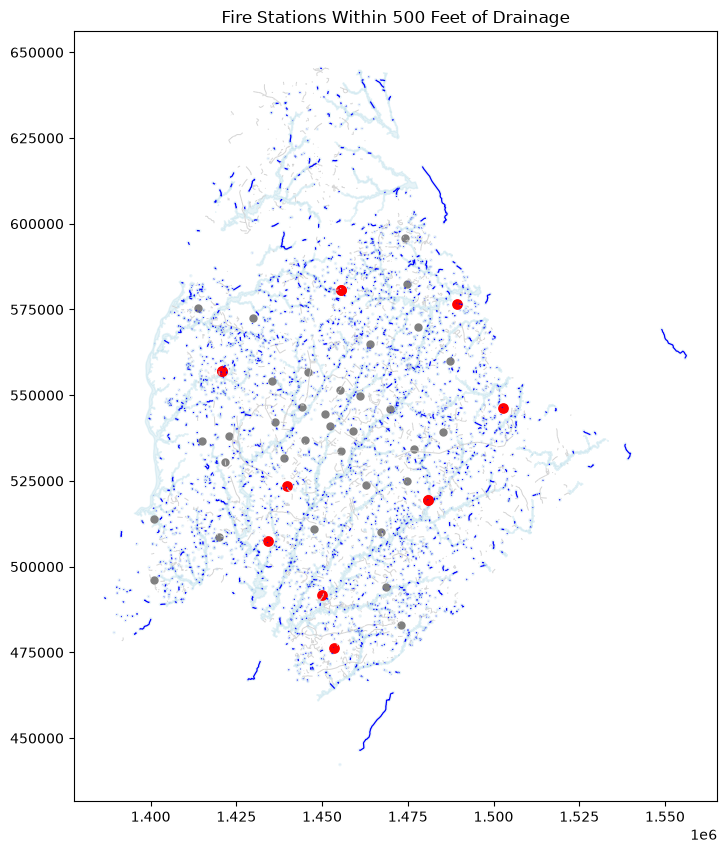

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

community.plot(ax=ax, color="lightblue", alpha=0.30, edgecolor="lightblue")
streets.plot(ax=ax, color="lightgray",linewidth=0.7)
drainage.plot(ax=ax, color="blue", linewidth=0.9)
drainage_buffer.plot(ax=ax, color="lightblue", alpha=0.25)
fire.plot(ax=ax, color="gray", markersize=25)
fire_near_drainage.plot(ax=ax, color="red", markersize=45) #its on top of gray points

ax.set_title("Fire Stations Within 500 Feet of Drainage")
plt.show()


In [13]:
drainage_buffer.to_file(f"{data_directory}/drainage_buffer.geojson",driver="GeoJSON")

Layer 3: Exposed Streets Near a Fire Station

In [14]:
fire_station_1 = fire.geometry.iloc[0]
flood_exposed_streets["distance_to_fire_ft"] = (flood_exposed_streets.geometry.distance(fire_station_1))
flood_exposed_streets[["distance_to_fire_ft", "geometry"]].head()

,distance_to_fire_ft,geometry
55,20957.556030,"LINESTRING (1432904.247 532846.083, 1432835.66..."
57,18665.935278,"LINESTRING (1443367.164 557514.583, 1443401.41..."
58,18497.080966,"LINESTRING (1443240.163 557253.25, 1443265.914..."
59,18711.268463,"LINESTRING (1443401.413 557584.25, 1443415.247..."
62,18126.901665,"LINESTRING (1443104.58 556751.333, 1443083.997..."


In [15]:
flood_exposed_streets["distance_to_fire_ft"].sort_values().head(10)

3279     3896.306183
2249     5320.184706
1009     8904.519139
1008     9117.716580
1002     9334.909919
1007     9458.024502
1005     9579.124139
1006     9790.327004
1003    10045.260512
145     10802.836142
Name: distance_to_fire_ft, dtype: float64

In [16]:
flood_streets_near_fire = flood_exposed_streets[flood_exposed_streets["distance_to_fire_ft"] <= 15840].copy()
#3 miles distance
flood_streets_near_fire.head()

,OBJECTID,ENABLED,E911,LASTEDITDATE,DATEADDED,USERNAME,ACTIONTYPE,PREFIXDIRECTION,STREETNAME,STANDTYPE,...,FULL_NAME,SHAPE.STLength(),geometry,index_right,STATUS,FLD_ZONE,DATE,Shape_Leng,Shape_Area,distance_to_fire_ft
145,18738127,1,62596,1633100441000,1626106110000,AHRENN,New,None,ACCLAIM,ST,...,2100 - 2142 ACCLAIM ST,293.102560,"LINESTRING (1459246.509 532616.274, 1459136.92...",76,EFFECTIVE,COMMUNITY FLOODPLAIN - FUTURE CONDITIONS,2014-02-19,8399.124856,9.085212e+05,10802.836142
1002,18738984,1,10179,1604040171000,946512000000,SCASTONGIA,New,None,ANDRILL,TER,...,706 - 714 ANDRILL TER,211.354136,"LINESTRING (1448004.247 549409.083, 1448017.91...",165,EFFECTIVE,COMMUNITY FLOODPLAIN - FUTURE CONDITIONS,2015-09-02,35062.887328,2.776705e+06,9334.909919
1003,18738985,1,11346,1604040245000,946512000000,SCASTONGIA,New,None,ANDRILL,TER,...,1000 - 1098 ANDRILL TER,666.489497,"LINESTRING (1448575.331 550436.916, 1448622.33...",165,EFFECTIVE,COMMUNITY FLOODPLAIN - FUTURE CONDITIONS,2015-09-02,35062.887328,2.776705e+06,10045.260512
1005,18738987,1,12013,1604040245000,946512000000,SCASTONGIA,New,None,ANDRILL,TER,...,800 - 898 ANDRILL TER,345.627465,"LINESTRING (1448209.914 549778.083, 1448238.49...",165,EFFECTIVE,COMMUNITY FLOODPLAIN - FUTURE CONDITIONS,2015-09-02,35062.887328,2.776705e+06,9579.124139
1006,18738988,1,11676,1604040245000,946512000000,SCASTONGIA,New,None,ANDRILL,TER,...,900 - 958 ANDRILL TER,314.746409,"LINESTRING (1448375.498 550081.416, 1448388.16...",165,EFFECTIVE,COMMUNITY FLOODPLAIN - FUTURE CONDITIONS,2015-09-02,35062.887328,2.776705e+06,9790.327004


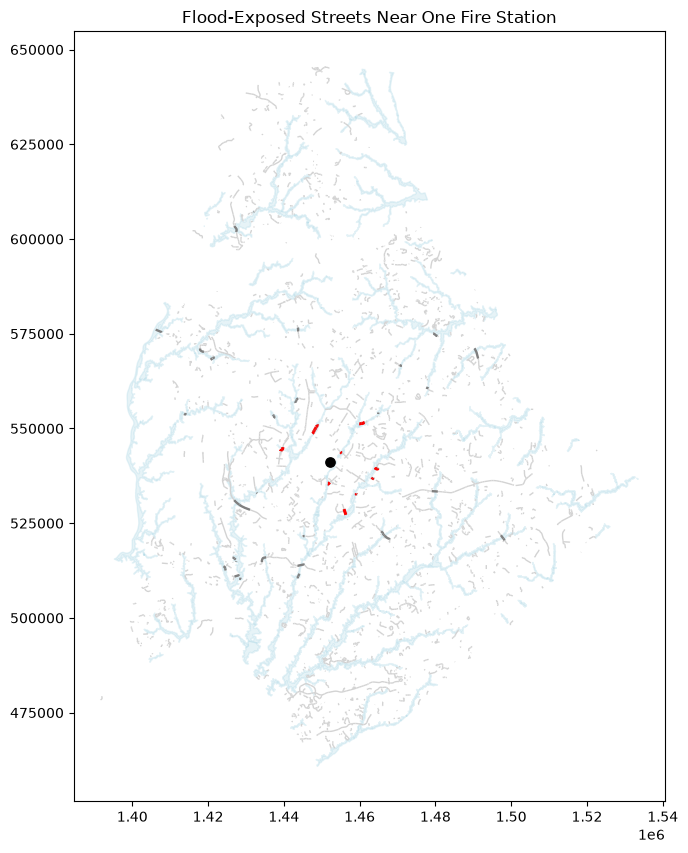

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))
community.plot(ax=ax, color="lightblue", alpha=0.30, edgecolor="lightblue")
streets.plot(ax=ax, color="lightgray", linewidth=1.0)
flood_exposed_streets.plot(ax=ax, color="gray", linewidth=1.7)
flood_streets_near_fire.plot(ax=ax, color="red", linewidth=2.2)
fire.iloc[[0]].plot(ax=ax, color="black", markersize=45)

ax.set_title("Flood-Exposed Streets Near One Fire Station")
plt.show()

In [18]:
flood_streets_near_fire.to_file(f"{data_directory}/flood_streets_near_fire.geojson",driver="GeoJSON")

AI usage: I used AI (ChatGPT) in order to fix my issues with the geojson query download. I experienced issues where it would always download as a text or json file, or in one case it was a geojson but showed Fire Station data for Californian coordinates instead of Charlotte, NC. I copy pasted the query page into ChatGPT and asked it how to fill in the fields, it gave me 2 fields that I really needed - Where: 1=1, Out Fields: *. With these filled out everything worked as intended. Used what the AI that pops up in a Google Search said for making some parts of the plots less vibrant, I forgot the command for alpha=.